# Build, curate, split & visualize the FP **sequence -> pKa** dataset

Integrates `build_peak_dataset.py` (dataset construction) and `curate_split_visualize.ipynb`
(outlier filtering + coordinated surrogate/oracle splits) into one workflow, but targets
**pKa** (the pH at which the chromophore is half-protonated -- i.e. the FP's pH sensitivity)
instead of the peak wavelengths or brightness.

End-to-end:
1. **Build** a `(sequence, pKa)` dataset from the fpbase-extractor protein export. A sample =
   one `(protein, state)` that is a fluorescent FP -- a standard-AA sequence with a reported `pka`
   **and** both peaks `ex_max`/`em_max`. Non-emissive chromoproteins (no `em_max`) are excluded.
   Multi-state sequences are collapsed to one row with the **same rule as `build_peak_dataset.py`**
   (drop sensors, dedup identical, drop ambiguous, keep the min-emission native precursor) so every
   sequence has one pKa target and nothing leaks across the split.
2. **Flag outliers** with the **same filter as `curate_split_visualize.ipynb`**: non-empty FPbase
   `cofactor`, nearest-neighbor 4-mer similarity < 0.10, and an explicit `frFAST`/`nirFAST` name flag.
3. **Visualize** NN-similarity and the ESM-2 embedding of the full dataset with outliers highlighted.
4. **Curate** = drop the flagged rows; write the curated dataset in `build_peak_dataset.py` layout.
5. **Split** into coordinated surrogate + oracle train/val/test (seed 0, 70/15/15) with disjoint val sets,
   `S_test subset O_train` and `O_test subset S_train` -- identical logic to the peak pipeline.

Artifacts are written under `training_data_pka/` (raw) and `training_data_pka/curated/`,
leaving the peak and brightness artifacts untouched. ESM-2 embeddings are reused from the peak
residue cache by sequence (viz only); the handful of sequences absent from the cache are embedded on
the fly, and if ESM is unavailable they are simply omitted from the t-SNE (the dataset/split never
depend on embeddings).

Unlike brightness (right-skewed, ~0-165, modeled in log space), **pKa is bounded and roughly
symmetric** (~0-12, median ~5.4), so it is modeled directly in pH units -- no `log1p`.

## 0. Build the `(sequence, pKa)` dataset

In [1]:
import csv, json, os, numpy as np
import build_peak_dataset as bpd   # reuse clean_seq + the exact multi-state collapse rule

PROT = '../fpbase-extractor/fpbase_output/fpbase_proteins.json'
TD_K = 'training_data_pka'          # pKa artifacts (parallel to peak 'training_data')
os.makedirs(TD_K, exist_ok=True)

proteins = json.load(open(PROT))
rows, seq_to_group = [], {}
skip_no_seq = skip_nonstd = skip_no_pka = 0
for p in proteins:
    seq, ok = bpd.clean_seq(p.get('seq'))
    if not seq:  skip_no_seq += 1;  continue
    if not ok:   skip_nonstd += 1;  continue
    for st in (p.get('states') or []):
        pk, ex, em = st.get('pka'), st.get('ex_max'), st.get('em_max')
        if pk is None or ex is None or em is None:   # a fluorescent FP with a pKa needs pka + both peaks
            skip_no_pka += 1;  continue
        gid = seq_to_group.setdefault(seq, len(seq_to_group))
        rows.append({
            'index': len(rows), 'slug': p.get('slug', ''), 'name': p.get('name', ''),
            'state': st.get('name') or 'default', 'seq_group': gid,
            'parent_organism': p.get('parent_organism') or '', 'switch_type': p.get('switch_type_label') or '',
            'oligomerization': p.get('oligomerization') or '',
            'pka': round(float(pk), 3), 'ex_max': round(float(ex), 1), 'em_max': round(float(em), 1),
            'ref_year': p.get('ref_year') or '', 'seq_len': len(seq),
            'aliases': '; '.join(p.get('aliases') or []), 'seq': seq,
        })

n_states = len(rows)
# --- collapse each >1-state seq_group to one row (identical rule to build_peak_dataset.py) ---
keep, collapse = bpd.collapse_seq_groups(rows)
rows = [rows[i] for i in keep]
regroup = {}
for new_idx, r in enumerate(rows):
    r['index'] = new_idx
    r['seq_group'] = regroup.setdefault(r['seq_group'], len(regroup))

pka = np.asarray([r['pka'] for r in rows], dtype=np.float32).reshape(-1, 1)   # (N,1)
np.save(f'{TD_K}/pka.npy', pka)
with open(f'{TD_K}/sequences.fasta', 'w') as fh:
    for r in rows:
        sid = ''.join(ch if (ch.isalnum() or ch in '-_.') else '_' for ch in f"{r['slug']}|{r['state']}")
        fh.write(f">{r['index']}|{sid}\n{r['seq']}\n")
cols = ['index','slug','name','state','seq_group','parent_organism','switch_type','oligomerization',
        'pka','ex_max','em_max','ref_year','seq_len','aliases','seq']
with open(f'{TD_K}/pka_assignments.csv', 'w', newline='') as fh:
    w = csv.DictWriter(fh, fieldnames=cols); w.writeheader(); w.writerows(rows)

n_uniq = len({r['seq'] for r in rows})
meta = {'source_proteins': PROT, 'target': 'pka', 'units': 'pH (dimensionless)',
        'n_samples': len(rows), 'n_unique_sequences': n_uniq,
        'pka_range': [float(pka.min()), float(pka.max())],
        'pka_median': float(np.median(pka)),
        'skipped_no_sequence': skip_no_seq, 'skipped_nonstandard_aa': skip_nonstd,
        'skipped_state_missing_pka_or_peak': skip_no_pka,
        'n_states_before_collapse': n_states, 'collapse': collapse,
        'note': 'pKa = FPbase-reported pH of half-maximal chromophore protonation per (protein, state); '
                'lower pKa = more acid-resistant fluorescence. Every sample is a fluorescent FP with both '
                'ex_max and em_max; non-emissive chromoproteins are excluded. Bounded, roughly symmetric '
                '(~0-12, median ~5.4) -- model directly in pH units, no log transform.',
        'citation': 'FPbase: Lambert TJ, Nat Methods 2019. Data (c) FPbase contributors.'}
json.dump(meta, open(f'{TD_K}/pka_meta.json', 'w'), indent=2)

print(f'built {len(rows)} samples ({n_uniq} unique seqs) from {n_states} pKa states -> {TD_K}/')
print(f"  pKa         {pka.min():.2f}-{pka.max():.2f}  (median {np.median(pka):.2f})")
print(f"  collapse    {collapse['counts']}")
print(f'  skipped     {skip_no_seq} no-seq, {skip_nonstd} non-standard-AA, {skip_no_pka} state-without-pka/peak')

built 397 samples (397 unique seqs) from 442 pKa states -> training_data_pka/
  pKa         0.00-8.60  (median 5.23)
  collapse    {'single_state': 365, 'drop_sensor': 3, 'keep_min_emission': 32, 'drop_ambiguous': 2}
  skipped     51 no-seq, 14 non-standard-AA, 557 state-without-pka/peak


## 1. Flag outliers  (cofactor | NN 4-mer < 0.10 | frFAST/nirFAST)

In [2]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity as cossim
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
try:
    import arcadia_pycolor as apc; apc.mpl.setup(); HAVE_APC = True
except Exception:
    HAVE_APC = False
import matplotlib.pyplot as plt
class _C:
    def __getattr__(self, k):
        return getattr(apc, k) if HAVE_APC else {'aegean':'#2b6c8f','amber':'#f6a200','rose':'#c5474b',
            'seaweed':'#3b8a6e','gray':'#9a9a9a','dragon':'#b23b3b','aster':'#7a5ea8'}.get(k, '#333')
C = _C()

# reload the freshly built pKa dataset
rows = list(csv.DictReader(open(f'{TD_K}/pka_assignments.csv'))); N = len(rows)
PKA = np.load(f'{TD_K}/pka.npy').astype(np.float32).ravel()
names = [r['name'] for r in rows]; slug = [r['slug'] for r in rows]
LEN = np.array([int(r['seq_len']) for r in rows])
EX  = np.array([float(r['ex_max']) for r in rows]); EM = np.array([float(r['em_max']) for r in rows])
seqs = [None]*N; h = None
for line in open(f'{TD_K}/sequences.fasta'):
    line = line.strip()
    if line.startswith('>'): h = int(line[1:].split('|')[0])
    elif line: seqs[h] = line

# (1) cofactor tag from the protein export
prot = json.load(open(PROT))
cofmap = {p['slug']: (p.get('cofactor') or '') for p in prot}
COF = np.array([cofmap.get(s, '') for s in slug])
f_cof = np.array([c.strip().lower() not in ('', 'none') for c in COF])
# (2) nearest-neighbor 4-mer cosine similarity < 0.10
Xk = CountVectorizer(analyzer='char', ngram_range=(4, 4)).fit_transform(seqs)
Sk = cossim(Xk); np.fill_diagonal(Sk, -1); NN = Sk.max(1)
f_nn = NN < 0.10
# (3) explicit frFAST / nirFAST (fluorogen-activating; peak/pKa set by exogenous dye)
f_fast = np.array([('nirfast' in n.lower() or 'frfast' in n.lower()) for n in names])
OUT = f_cof | f_nn | f_fast

print(f'N={N} | outliers={OUT.sum()}  (cofactor {f_cof.sum()}, NN<0.10 {f_nn.sum()}, frFAST/nirFAST {f_fast.sum()})')
print(f'  overlap: cofactor&NN {(f_cof&f_nn).sum()} | unique-to-NN {(f_nn&~f_cof&~f_fast).sum()} | unique-to-FAST {(f_fast&~f_cof&~f_nn).sum()}')
print('frFAST/nirFAST rows:', [names[i] for i in np.where(f_fast)[0]])

N=397 | outliers=33  (cofactor 31, NN<0.10 6, frFAST/nirFAST 0)
  overlap: cofactor&NN 4 | unique-to-NN 2 | unique-to-FAST 0
frFAST/nirFAST rows: []


### Build mean-pooled ESM-2 embeddings (viz only)

Reuse the peak residue cache (`training_data/esm_residue_fp16.npy`) by **sequence**; embed any sequence
absent from the cache on the fly via `peak_models.resid_embed`. If ESM is unavailable, those few points
are dropped from the t-SNE only -- the dataset and splits never use embeddings.

In [3]:
pk = list(csv.DictReader(open('training_data/peak_assignments.csv')))
Hc = np.load('training_data/esm_residue_fp16.npy', mmap_mode='r')
Lc = np.load('training_data/esm_residue_len.npy')
seq2mp = {}
for j, r in enumerate(pk):
    s = r['seq']
    if s not in seq2mp:
        L = int(Lc[j]); seq2mp[s] = np.asarray(Hc[j, :L], dtype=np.float32).mean(0)

emb = np.full((N, 1280), np.nan, dtype=np.float32)
missing = []
for i, s in enumerate(seqs):
    if s in seq2mp: emb[i] = seq2mp[s]
    else: missing.append(i)
print(f'{N - len(missing)}/{N} sequences embedded from peak cache; {len(missing)} need on-the-fly ESM')

if missing:
    try:
        import torch, peak_models as pm
        dev = torch.device('mps') if (getattr(torch.backends,'mps',None) and torch.backends.mps.is_available()) \
              else (torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'))
        Hm, mask = pm.resid_embed([seqs[i] for i in missing], dev)
        mp = ((Hm * mask.unsqueeze(-1)).sum(1) / mask.sum(1, keepdim=True).clamp(min=1)).cpu().numpy()
        for k, i in enumerate(missing): emb[i] = mp[k]
        print(f'  embedded {len(missing)} missing sequences via ESM-2 on {dev}')
    except Exception as e:
        print(f'  ESM unavailable ({type(e).__name__}); {len(missing)} points dropped from t-SNE only')
emb_ok = ~np.isnan(emb).any(1)

395/397 sequences embedded from peak cache; 2 need on-the-fly ESM
  embedded 2 missing sequences via ESM-2 on mps


## 2. Visualize NN similarity + ESM-2 embedding (full dataset, outliers flagged)

Left: nearest-neighbor 4-mer similarity with the 0.10 threshold. Right: 2-D t-SNE of the mean-pooled
ESM-2 embeddings; kept samples in gray, outliers overlaid by reason. A point can carry more than one marker.

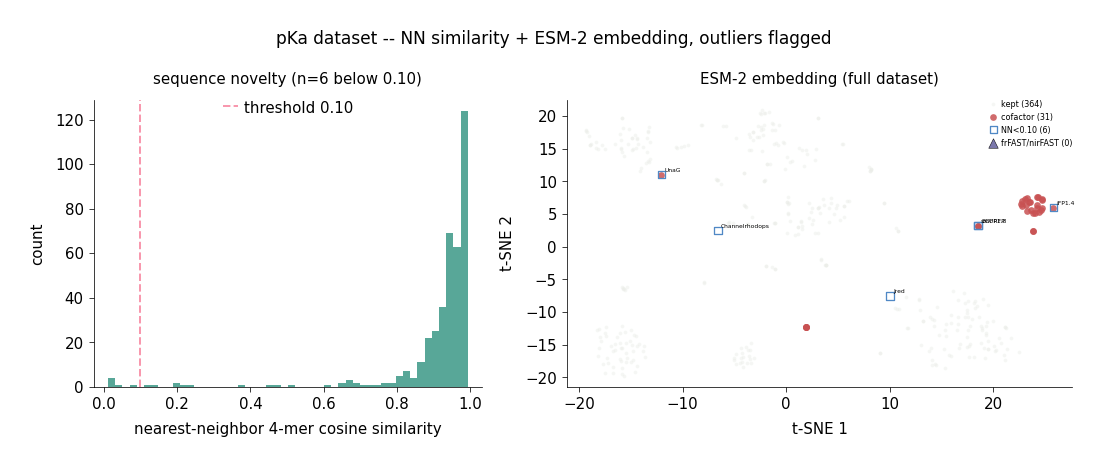

In [4]:
vis = emb_ok                                        # only points with an embedding go into t-SNE
E = emb[vis]
TS_v = TSNE(2, random_state=0, perplexity=30, init='pca').fit_transform(
        PCA(50, random_state=0).fit_transform((E - E.mean(0)) / (E.std(0) + 1e-6)))
TS = np.full((N, 2), np.nan); TS[vis] = TS_v
def _m(flag): return flag & vis                     # restrict overlays to embedded points

fig, ax = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [1, 1.3]})
ax[0].hist(NN, bins=50, color=C.seaweed, alpha=0.85); ax[0].axvline(0.10, color=C.rose, ls='--', label='threshold 0.10')
ax[0].set_xlabel('nearest-neighbor 4-mer cosine similarity'); ax[0].set_ylabel('count')
ax[0].set_title(f'sequence novelty (n={int(f_nn.sum())} below 0.10)'); ax[0].legend()
ax[1].scatter(TS[_m(~OUT),0], TS[_m(~OUT),1], s=14, c=C.gray, alpha=0.45, label=f'kept ({(~OUT).sum()})')
ax[1].scatter(TS[_m(f_cof),0], TS[_m(f_cof),1], s=45, c=C.dragon, alpha=0.85, label=f'cofactor ({f_cof.sum()})')
ax[1].scatter(TS[_m(f_nn),0], TS[_m(f_nn),1], s=55, marker='s', facecolors='none', edgecolors=C.aegean, lw=1.3, label=f'NN<0.10 ({f_nn.sum()})')
ax[1].scatter(TS[_m(f_fast),0], TS[_m(f_fast),1], s=90, marker='^', c=C.aster, edgecolors='k', lw=0.5, label=f'frFAST/nirFAST ({f_fast.sum()})')
for i in np.where(_m(f_fast | f_nn))[0]:
    ax[1].annotate(names[i][:14], (TS[i,0], TS[i,1]), fontsize=6, xytext=(3,3), textcoords='offset points')
ax[1].set_xlabel('t-SNE 1'); ax[1].set_ylabel('t-SNE 2'); ax[1].set_title('ESM-2 embedding (full dataset)'); ax[1].legend(fontsize=8)
plt.suptitle('pKa dataset -- NN similarity + ESM-2 embedding, outliers flagged'); plt.tight_layout(); plt.show()

## 3. Create the curated dataset (drop flagged outliers)

In [5]:
keep = np.where(~OUT)[0]; Nc = len(keep)
cur = f'{TD_K}/curated'; os.makedirs(cur, exist_ok=True)
np.save(f'{cur}/keep_index.npy', keep)
np.save(f'{cur}/pka.npy', PKA[keep].astype(np.float32).reshape(-1, 1))
with open(f'{cur}/sequences.fasta', 'w') as fh:
    for newi, oldi in enumerate(keep): fh.write(f'>{newi}|{slug[oldi]}\n{seqs[oldi]}\n')
cols = list(rows[0].keys()) + ['orig_index']
with open(f'{cur}/pka_assignments.csv', 'w', newline='') as fh:
    w = csv.DictWriter(fh, fieldnames=cols); w.writeheader()
    for newi, oldi in enumerate(keep):
        r = dict(rows[oldi]); r['orig_index'] = oldi; r['index'] = newi; w.writerow(r)
reasons = {'cofactor': int(f_cof.sum()), 'NN<0.10': int(f_nn.sum()), 'frFAST/nirFAST': int(f_fast.sum()),
           'total_dropped': int(OUT.sum()), 'kept': int(Nc), 'original': int(N)}
json.dump({'filter': 'cofactor | NN4mer<0.10 | name~(frFAST|nirFAST)', 'target': 'pka',
           'counts': reasons, 'dropped_names': [names[i] for i in np.where(OUT)[0]]},
          open(f'{cur}/curate_meta.json', 'w'), indent=2)
print(f'curated: kept {Nc} / {N}  (dropped {OUT.sum()}) -> {cur}/')
print('dropped breakdown:', reasons)

curated: kept 364 / 397  (dropped 33) -> training_data_pka/curated/
dropped breakdown: {'cofactor': 31, 'NN<0.10': 6, 'frFAST/nirFAST': 0, 'total_dropped': 33, 'kept': 364, 'original': 397}


## 4. Train/val/test split -- coordinated surrogate + oracle

Same logic as `surrogate_oracle_peak_dual.ipynb` / `curate_split_visualize.ipynb` (seed 0, 70/15/15) on the
**curated** rows: two coordinated splits with disjoint val sets, `S_test subset O_train`, `O_test subset S_train`.

In [6]:
curows = list(csv.DictReader(open(f'{cur}/pka_assignments.csv')))
PKAc = np.load(f'{cur}/pka.npy').astype(np.float32).ravel()
LENc = np.array([int(r['seq_len']) for r in curows]); cnames = [r['name'] for r in curows]
EXc  = np.array([float(r['ex_max']) for r in curows]); EMc = np.array([float(r['em_max']) for r in curows])
embc = emb[keep]; okc = emb_ok[keep]

SEED = 0; perm = np.random.default_rng(SEED).permutation(Nc)
n_te = int(round(.15 * Nc)); n_va = int(round(.15 * Nc))
Srole = np.array(['train']*Nc); Srole[perm[:n_te]] = 'test'; Srole[perm[n_te:n_te+n_va]] = 'val'
s_train = perm[n_te+n_va:]; st = np.random.default_rng(SEED+1).permutation(s_train)
Orole = np.array(['train']*Nc); Orole[st[:n_te]] = 'test'; Orole[st[n_te:n_te+n_va]] = 'val'
assert np.all(Orole[Srole=='test']=='train') and np.all(Srole[Orole=='test']=='train')
with open(f'{cur}/dual_splits.csv', 'w', newline='') as fh:
    w = csv.writer(fh); w.writerow(['index','name','surrogate_role','oracle_role'])
    for i in range(Nc): w.writerow([i, cnames[i], Srole[i], Orole[i]])
def cnt(a): return {b: int((a==b).sum()) for b in ('train','val','test')}
print(f'curated N={Nc}')
print('surrogate split:', cnt(Srole)); print('oracle    split:', cnt(Orole))

# shared t-SNE layout for the curated set (embedded points only)
visc = okc; Ec = embc[visc]
TSc_v = TSNE(2, random_state=0, perplexity=30, init='pca').fit_transform(
          PCA(50, random_state=0).fit_transform((Ec - Ec.mean(0)) / (Ec.std(0) + 1e-6)))
TSc = np.full((Nc, 2), np.nan); TSc[visc] = TSc_v
ROLECOL = {'train': C.gray, 'val': C.aegean, 'test': C.amber}

curated N=364
surrogate split: {'train': 254, 'val': 55, 'test': 55}
oracle    split: {'train': 254, 'val': 55, 'test': 55}


### 4b. Dual-split bipartite map

How the surrogate roles map onto the oracle roles: node size ~ #FPs in that role; edge width/label ~ #FPs
shared between a surrogate role and an oracle role. By construction `S_test subset O_train` and
`O_test subset S_train` with disjoint val sets.

surrogate-role -> oracle-role contingency:
  S_train -> O_train 144, O_val 55, O_test 55
  S_val   -> O_train 55, O_val 0, O_test 0
  S_test  -> O_train 55, O_val 0, O_test 0


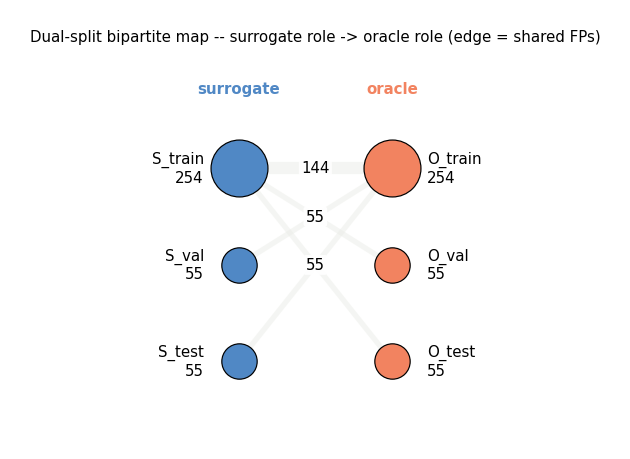

In [7]:
roles = ['train','val','test']
M = {(s,o): int(((Srole==s)&(Orole==o)).sum()) for s in roles for o in roles}
Stot = {s: int((Srole==s).sum()) for s in roles}; Otot = {o: int((Orole==o).sum()) for o in roles}
print('surrogate-role -> oracle-role contingency:')
for s in roles: print(f'  S_{s:5s} -> ' + ', '.join(f'O_{o} {M[(s,o)]}' for o in roles))
yp = {'train':2,'val':1,'test':0}; LX, RX = 0.0, 2.0; cmax = max(M.values())
fig, ax = plt.subplots(figsize=(6,6))
for s in roles:
    for o in roles:
        c = M[(s,o)]
        if c == 0: continue
        ax.plot([LX,RX],[yp[s],yp[o]], lw=1.2+11*c/cmax, color=C.gray, alpha=0.5, zorder=1, solid_capstyle='round')
        ax.text(LX+0.5*(RX-LX), yp[s]+0.5*(yp[o]-yp[s]), str(c), ha='center', va='center', fontsize=15, zorder=3,
                bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.85))
for s in roles:
    ax.scatter([LX],[yp[s]], s=700+10*Stot[s], color=C.aegean, ec='k', lw=1.2, zorder=2)
    ax.text(LX-0.45, yp[s], f'S_{s}\n{Stot[s]}', ha='right', va='center', fontsize=15)
for o in roles:
    ax.scatter([RX],[yp[o]], s=700+10*Otot[o], color=C.amber, ec='k', lw=1.2, zorder=2)
    ax.text(RX+0.45, yp[o], f'O_{o}\n{Otot[o]}', ha='left', va='center', fontsize=15)
ax.text(LX, 2.78, 'surrogate', ha='center', fontsize=15, color=C.aegean, fontweight='bold')
ax.text(RX, 2.78, 'oracle',    ha='center', fontsize=15, color=C.amber,  fontweight='bold')
ax.set_xlim(-1.6,3.6); ax.set_ylim(-0.7,3.15); ax.axis('off')
ax.set_title('Dual-split bipartite map -- surrogate role -> oracle role (edge = shared FPs)')
plt.tight_layout(); plt.show()

## 5. Visualize the curated splits

For each split (surrogate, then oracle): the ESM-2 embedding (t-SNE) colored by role, plus **pKa**,
**ex_max**, **em_max**, and **length** distributions as density histograms per role -- to check the split
is representative across the pKa, spectral, and length ranges. pKa is bounded and roughly symmetric, so it
is plotted on a linear axis (no log scale).

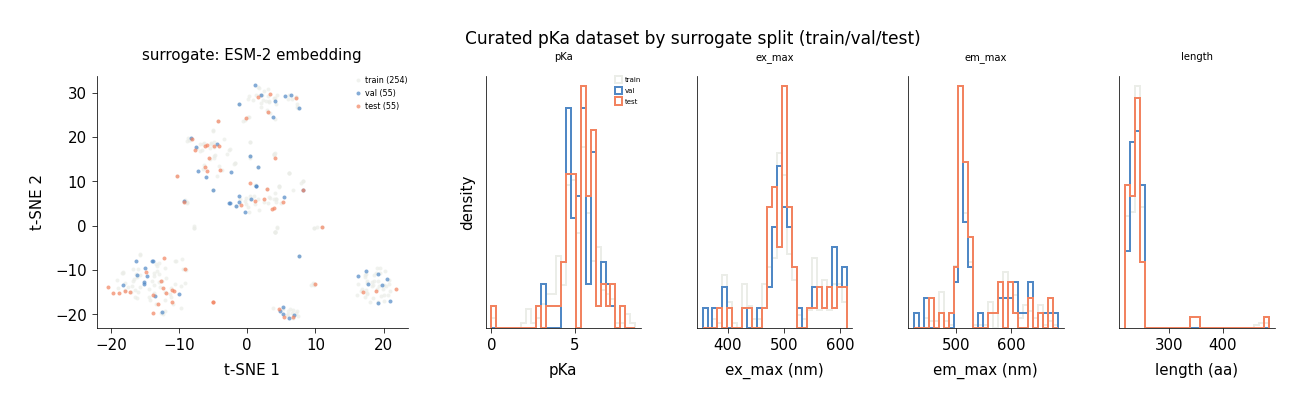

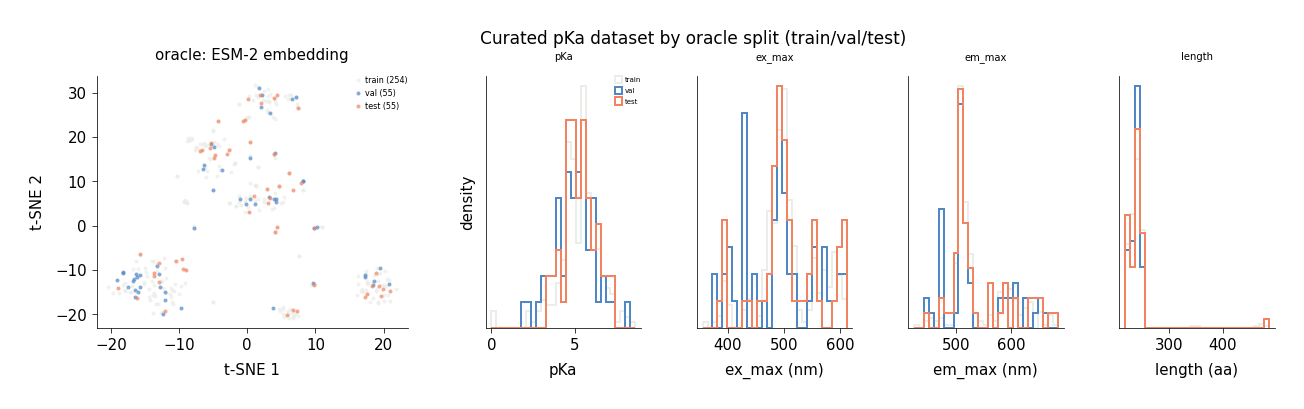

In [8]:
def viz_split(role, tag):
    fig = plt.figure(figsize=(18, 4.6))
    ax0 = fig.add_axes([0.04, 0.12, 0.24, 0.76])
    for r in ['train','val','test']:
        m = (role==r) & visc; ax0.scatter(TSc[m,0], TSc[m,1], s=16, c=ROLECOL[r], alpha=0.7, label=f'{r} ({int((role==r).sum())})')
    ax0.set_xlabel('t-SNE 1'); ax0.set_ylabel('t-SNE 2'); ax0.set_title(f'{tag}: ESM-2 embedding'); ax0.legend(fontsize=8)
    panels = [(PKAc, 'pKa', False), (EXc, 'ex_max (nm)', False), (EMc, 'em_max (nm)', False), (LENc, 'length (aa)', False)]
    for k, (arr, lab, logx) in enumerate(panels):
        a = fig.add_axes([0.34 + 0.163*k, 0.12, 0.12, 0.76])
        if logx:
            pos = arr[arr > 0]; bins = np.logspace(np.log10(pos.min()), np.log10(pos.max()), 30); a.set_xscale('log')
        else:
            bins = np.linspace(arr.min(), arr.max(), 30)
        for r in ['train','val','test']:
            a.hist(arr[role==r], bins=bins, density=True, histtype='step', lw=2, color=ROLECOL[r], label=r)
        a.set_xlabel(lab); a.set_yticks([])
        if k == 0: a.set_ylabel('density'); a.legend(fontsize=7)
        a.set_title(lab.split()[0], fontsize=10)
    plt.suptitle(f'Curated pKa dataset by {tag} split (train/val/test)', y=1.02); plt.show()

viz_split(Srole, 'surrogate')
viz_split(Orole, 'oracle')

## 6. Data learning curve for pKa -- is one split enough, or do we need the dual scheme?

How does **test** error improve as the **training set grows**? We hold out a **fixed 15% test set** (seed 0)
from the curated dataset (**85/15** train/test), then train a CNN regressor on increasing fractions of the
remaining **85% pool** and evaluate on that same fixed test set -- mirroring `learning_curve.ipynb` for peaks.

pKa is bounded and roughly symmetric (~0-12), so the model is trained **directly on pKa** (standardized on
the train split, analogous to `StandardizedPeaks`); MAE is reported in **pH units**. Every fit's weights are
cached to `trained_models_pka/lc_models/` so re-runs are instant.

**Why this answers the split question.** The dual surrogate/oracle scheme spends the data twice (each model
holds out its own 15% test, seen by the other during training). The learning curve tells us (1) whether the
training pool is on the plateau -- i.e. whether error is data-limited or model/label-limited -- and (2) how
big the train-vs-test gap is. A large gap and a still-descending curve argue that carving out two 15% holdouts
is expensive and that a single, larger training split (with test-set-only trust) is the safer read.

### 6.0 Setup -- curated pKa, per-residue ESM-2 embeddings, fixed 85/15 test

In [9]:
import torch, peak_models as pm
dev = torch.device('mps') if (getattr(torch.backends,'mps',None) and torch.backends.mps.is_available()) \
      else (torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'))
TDM_K = 'trained_models_pka'; os.makedirs(TDM_K, exist_ok=True)

lc_rows = list(csv.DictReader(open(f'{cur}/pka_assignments.csv'))); Nlc = len(lc_rows)
lc_seqs = [None]*Nlc; h=None
for line in open(f'{cur}/sequences.fasta'):
    line=line.strip()
    if line.startswith('>'): h=int(line[1:].split('|')[0])
    elif line: lc_seqs[h]=line
y = np.load(f'{cur}/pka.npy').astype(np.float32).ravel()                 # (N,) pKa, modeled directly in pH units

# per-residue ESM-2 embeddings for the curated FPs: pull each sequence from the peak residue cache,
# embedding on the fly only the few sequences the cache lacks (same reuse-by-sequence trick as the viz).
pk = list(csv.DictReader(open('training_data/peak_assignments.csv')))
Hcache = np.load('training_data/esm_residue_fp16.npy', mmap_mode='r')
Lcache = np.load('training_data/esm_residue_len.npy')
seq2row = {}
for j, r in enumerate(pk): seq2row.setdefault(r['seq'], j)
Ls = np.array([len(s) for s in lc_seqs], dtype=np.int64); Lmax = int(Ls.max())
H = np.zeros((Nlc, Lmax, pm.D_IN), dtype=np.float16)
miss = []
for i, s in enumerate(lc_seqs):
    if s in seq2row:
        j = seq2row[s]; L = int(Lcache[j]); H[i,:L] = Hcache[j,:L]
    else: miss.append(i)
if miss:
    Hm, mk = pm.resid_embed([lc_seqs[i] for i in miss], dev)
    for k, i in enumerate(miss): H[i,:Ls[i]] = Hm[k,:Ls[i]].cpu().numpy().astype(np.float16)
    print(f'embedded {len(miss)} cache-missing sequences on {dev}')
Ht = torch.tensor(H); ar = torch.arange(Lmax); Yt = torch.tensor(y, device=dev).unsqueeze(1)

# fixed held-out 15% test (seed 0); the remaining 85% is the training pool
perm = np.random.default_rng(0).permutation(Nlc); n_te = int(round(0.15*Nlc))
TEST = perm[:n_te]; POOL = perm[n_te:]
print(f'device {dev} | curated N={Nlc} | fixed 15% test={len(TEST)} | 85% pool={len(POOL)}')

def batches(idx, bs=32, shuffle=False, rng=None):
    idx = np.array(idx)
    if shuffle: rng.shuffle(idx)
    for i in range(0, len(idx), bs):
        b = idx[i:i+bs]
        yield Ht[b].float().to(dev), (ar.unsqueeze(0) < torch.tensor(Ls[b]).unsqueeze(1)).to(dev), b
def mae_pka(net, idx):
    net.eval(); ps=[]
    with torch.no_grad():
        for Hb, mk_, b in batches(idx): ps.append(net(Hb, mk_).cpu().numpy())
    P = np.concatenate(ps).ravel()
    return float(np.abs(P - y[idx]).mean())
def train_eval(pool, tr_idx, te_idx, seed, epochs=70, save_path=None):
    torch.manual_seed(seed); rng = np.random.default_rng(100+seed)
    mean = np.array([y[tr_idx].mean()], np.float32); std = np.array([y[tr_idx].std()+1e-6], np.float32)
    sd = torch.tensor(std, device=dev)
    spec = dict(arch='cnn', pool=pool, conv_ch=128, k=5, hidden=256, nl=2)
    net = pm.wrap(pm.build_base(spec, dev, out=1, drop=0.2), mean, std, dev)
    opt = torch.optim.Adam(net.parameters(), 1e-3, weight_decay=1e-4)
    for ep in range(epochs):
        net.train()
        for Hb, mk_, b in batches(tr_idx, shuffle=True, rng=rng):
            opt.zero_grad()
            (((net(Hb, mk_) - Yt[torch.as_tensor(b, device=dev)]) / sd)**2).mean().backward(); opt.step()
    if save_path is not None:
        pm.save_model(save_path, net.base, dict(spec, drop=0.2, out=1, mean=mean, std=std,
                                                n_train=len(tr_idx), seed=seed))
    return mae_pka(net, te_idx), mae_pka(net, tr_idx)

embedded 2 cache-missing sequences on mps
device mps | curated N=364 | fixed 15% test=55 | 85% pool=309


### 6.1 Sweep training-set size (cached; 3 subset draws per point)

In [10]:
FRACS=[0.1,0.2,0.5,0.8,1.0]; SEEDS=[0,1,2]; POOLS=['max','concat']; EPOCHS=70
LC_CACHE=f'{TDM_K}/pka_learning_curve_sweep.json'
LC_DIR=f'{TDM_K}/lc_models'; os.makedirs(LC_DIR, exist_ok=True)
def lc_path(pool, f, sd): return f'{LC_DIR}/cnn-{pool}_p{int(round(f*100))}_s{sd}.pt'
if os.path.exists(LC_CACHE):
    res = json.load(open(LC_CACHE)); print(f'loaded sweep cache: {LC_CACHE}')
    for pool in POOLS:
        r = res[pool]
        for i, f in enumerate(r['frac']):
            print(f"  cnn-{pool:6} {int(f*100):3d}% pool | n_train={r['n'][i]:4d} | test MAE {r['te_mean'][i]:.3f} +/- {r['te_std'][i]:.3f} pKa | train MAE {r['tr_mean'][i]:.3f}")
else:
    res = {p: {'n':[], 'frac':[], 'te_mean':[], 'te_std':[], 'tr_mean':[], 'tr_std':[]} for p in POOLS}
    for pool in POOLS:
        print(f'--- cnn-{pool} ---')
        for f in FRACS:
            n = int(round(f*len(POOL))); te, tr = [], []
            for sd in SEEDS:
                sub = np.random.default_rng(sd).choice(POOL, n, replace=False)
                t_te, t_tr = train_eval(pool, sub, TEST, sd, epochs=EPOCHS, save_path=lc_path(pool, f, sd))
                te.append(t_te); tr.append(t_tr)
            r = res[pool]; r['n'].append(n); r['frac'].append(f)
            r['te_mean'].append(float(np.mean(te))); r['te_std'].append(float(np.std(te)))
            r['tr_mean'].append(float(np.mean(tr))); r['tr_std'].append(float(np.std(tr)))
            print(f'  {int(f*100):3d}% pool | n_train={n:4d} | test MAE {np.mean(te):.3f} +/- {np.std(te):.3f} pKa | train MAE {np.mean(tr):.3f}')
    json.dump(res, open(LC_CACHE,'w'), indent=2)
    print(f'saved sweep cache: {LC_CACHE}  ({len(FRACS)*len(SEEDS)*len(POOLS)} checkpoints -> {LC_DIR}/)')

--- cnn-max ---
   10% pool | n_train=  31 | test MAE 0.881 +/- 0.058 pKa | train MAE 0.092
   20% pool | n_train=  62 | test MAE 0.885 +/- 0.039 pKa | train MAE 0.275
   50% pool | n_train= 154 | test MAE 0.897 +/- 0.057 pKa | train MAE 0.175
   80% pool | n_train= 247 | test MAE 0.727 +/- 0.025 pKa | train MAE 0.256
  100% pool | n_train= 309 | test MAE 0.702 +/- 0.027 pKa | train MAE 0.203
--- cnn-concat ---
   10% pool | n_train=  31 | test MAE 0.979 +/- 0.103 pKa | train MAE 0.138
   20% pool | n_train=  62 | test MAE 0.893 +/- 0.086 pKa | train MAE 0.114
   50% pool | n_train= 154 | test MAE 0.865 +/- 0.104 pKa | train MAE 0.208
   80% pool | n_train= 247 | test MAE 0.700 +/- 0.049 pKa | train MAE 0.263
  100% pool | n_train= 309 | test MAE 0.691 +/- 0.009 pKa | train MAE 0.248
saved sweep cache: trained_models_pka/pka_learning_curve_sweep.json  (30 checkpoints -> trained_models_pka/lc_models/)


### 6.2 Learning curve

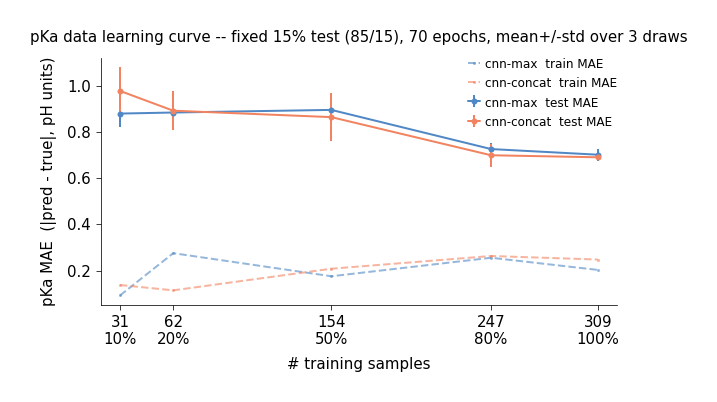

cnn-max: test MAE 0.881 @ 31 (10%) -> 0.702 pKa @ 309 (100%); train-test gap at full = +0.499 pKa
cnn-concat: test MAE 0.979 @ 31 (10%) -> 0.691 pKa @ 309 (100%); train-test gap at full = +0.443 pKa


In [11]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
col = {'max': C.aegean, 'concat': C.amber}
for pool in POOLS:
    r = res[pool]; n = np.array(r['n'])
    ax.errorbar(n, r['te_mean'], yerr=r['te_std'], marker='o', capsize=3, color=col[pool], label=f'cnn-{pool}  test MAE')
    ax.plot(n, r['tr_mean'], ls='--', marker='.', color=col[pool], alpha=0.6, label=f'cnn-{pool}  train MAE')
ax.set_xlabel('# training samples'); ax.set_ylabel('pKa MAE  (|pred - true|, pH units)')
ax.set_title('pKa data learning curve -- fixed 15% test (85/15), 70 epochs, mean+/-std over 3 draws')
ax.legend(fontsize=12); ax.set_xticks(res['max']['n'])
ax.set_xticklabels([f'{n}\n{int(f*100)}%' for n, f in zip(res['max']['n'], res['max']['frac'])])
plt.tight_layout(); fig.savefig(f'{TDM_K}/pka_learning_curve_85_15.png', dpi=130, bbox_inches='tight'); plt.show()
for pool in POOLS:
    r = res[pool]
    print(f"cnn-{pool}: test MAE {r['te_mean'][0]:.3f} @ {r['n'][0]} (10%) -> {r['te_mean'][-1]:.3f} pKa @ {r['n'][-1]} (100%); "
          f"train-test gap at full = {r['te_mean'][-1]-r['tr_mean'][-1]:+.3f} pKa")

### 6.3 Train vs test parity -- where is evaluation trustworthy?

Reloads the full-pool `cnn-concat` (seed 0 -- the top point of the curve, cached in 6.1) and predicts pKa
for every curated FP. Parity plots split by 85/15 membership show the gap between the **train** fit (optimistic
-- the model saw these labels) and the **held-out test** fit (the honest estimate of generalization).

group   n    MAE(pKa)   R2   Spearman
  train pool    309  0.274     0.91     0.96
  held-out test   55  0.683     0.22     0.55


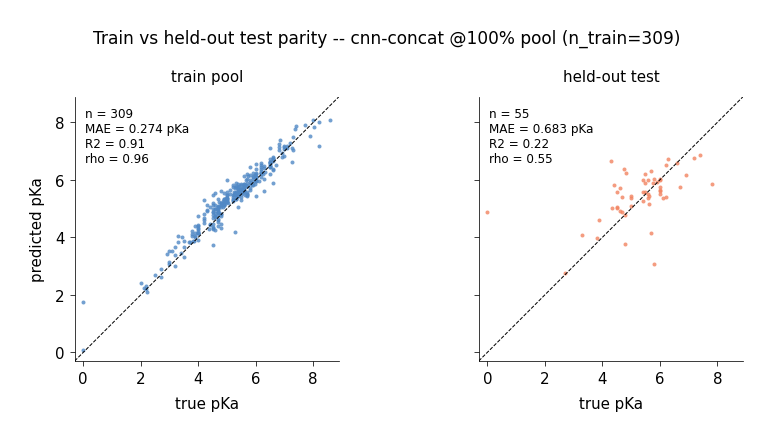

In [12]:
from scipy.stats import spearmanr
FULL_POOL='concat'; FULL_SEED=0; mpath = lc_path(FULL_POOL, 1.0, FULL_SEED)
if not os.path.exists(mpath):                       # 6.1 not run yet -> train just this one fit
    train_eval(FULL_POOL, POOL, TEST, FULL_SEED, epochs=EPOCHS, save_path=mpath)
base, ck = pm.load_model(mpath, dev, out=1); net = pm.wrap(base, ck['mean'], ck['std'], dev)
net.eval(); ps=[]
with torch.no_grad():
    for Hb, mk_, b in batches(np.arange(Nlc)): ps.append(net(Hb, mk_).cpu().numpy())
pred = np.concatenate(ps).ravel()
is_test = np.zeros(Nlc, bool); is_test[TEST] = True
def _r2(t, p): return 1 - np.sum((p-t)**2)/np.sum((t-t.mean())**2)
fig, axes = plt.subplots(1, 2, figsize=(12, 5.6), sharex=True, sharey=True)
lim = [y.min()-0.3, y.max()+0.3]
print('group   n    MAE(pKa)   R2   Spearman')
for ax, (name, m, cc) in zip(axes, [('train pool', ~is_test, C.aegean), ('held-out test', is_test, C.amber)]):
    idx = np.where(m)[0]; t = y[idx]; p = pred[idx]
    mae = np.abs(p-t).mean(); r2 = _r2(t, p); rho = spearmanr(t, p)[0]
    print(f'  {name:12} {len(idx):4d}  {mae:.3f}    {r2:5.2f}    {rho:5.2f}')
    ax.plot(lim, lim, ls='--', color='k', lw=1)
    ax.scatter(t, p, s=16, alpha=0.8, color=cc)
    ax.text(0.04, 0.96, f'n = {len(idx)}\nMAE = {mae:.3f} pKa\nR2 = {r2:.2f}\nrho = {rho:.2f}', transform=ax.transAxes, va='top', fontsize=12)
    ax.set_xlabel('true pKa'); ax.set_title(name); ax.set_box_aspect(1); ax.set_xlim(lim); ax.set_ylim(lim)
axes[0].set_ylabel('predicted pKa')
plt.suptitle(f'Train vs held-out test parity -- cnn-{FULL_POOL} @100% pool (n_train={ck.get("n_train")})')
plt.tight_layout(); fig.savefig(f'{TDM_K}/pka_parity_train_vs_test.png', dpi=130, bbox_inches='tight'); plt.show()

### 6.4 Reading the curve for the dual-split decision

Interpretation (see the printed numbers and the two figures above):
- **Is the data enough?** If the test-MAE curve is still descending at 100% pool, pKa prediction is
  **data-limited** -- every held-out sample is costly, which argues *against* spending 30% of the set on two
  separate 15% holdouts (surrogate test + oracle test). If it has plateaued, the split budget is affordable.
- **Where is evaluation trustworthy?** The train-vs-test parity gap is the honest-error tax: the **train** fit is
  optimistic (labels were seen), so only the **held-out test** R2/MAE should be trusted when reporting model
  quality. This is the core reason the dual scheme keeps a real, unseen test set for each model rather than
  trusting in-sample fit.
- **One model or two?** The dual surrogate/oracle design exists so each model's test set is *in-sample* for the
  other -- enabling the in-sample-vs-OOD design evaluation. If the learning curve shows a small train-test gap
  and a plateau, a **single** regressor with one clean 85/15 split is a defensible, data-efficient alternative;
  if the gap is large or the curve steep, the redundancy of two coordinated models (and the extra held-out
  data it protects) is worth the cost. The cached checkpoints let you reload any fit without retraining.

## 7. Score the guided designs with the full-pool pKa model

The guided designs in `peak_designs/` were optimized for **peak** (ex/em), not pKa -- so predicting their
pKa with the full-pool model (section 6.1) is an **off-target check**: do the peak-designed variants keep,
raise, or lower predicted pKa (pH sensitivity) relative to their scaffold FP?

We reload all six **100%-pool** checkpoints (`cnn-max` + `cnn-concat`, seeds 0/1/2), embed every designed
sequence once with ESM-2, and report the **ensemble mean +/- std** of predicted pKa. Each design's **scaffold
uses the FPbase ground-truth pKa** (looked up by sequence, not predicted) as the comparison baseline -- so
`delta_vs_scaffold` measures the design against the scaffold's real measured value, and the round-0 point
(which reuses the scaffold sequence) directly shows the model's error on that scaffold. Results are written to
`peak_designs/pka_scored.csv`. Read the design predictions as **relative rankings** rather than exact values,
in line with the held-out R2/Spearman from section 6.3.

In [13]:
import glob
design_files = sorted(f for f in glob.glob('peak_designs/**/*.csv', recursive=True)
                      if 'archive' not in f and os.path.basename(f).startswith('design_'))
drows = []
for f in design_files:
    variant = os.path.relpath(os.path.dirname(f), 'peak_designs')
    variant = 'default' if variant == '.' else variant
    for r in csv.DictReader(open(f)):
        drows.append({'variant': variant, 'pair': r.get('example',''), 'round': r.get('round',''),
                      'lam_used': r.get('lam_used',''), 'ident_to_scaffold': r.get('ident_to_scaffold',''),
                      'pred_ex': r.get('pred_ex',''), 'pred_em': r.get('pred_em',''),
                      'scaffold_name': r.get('scaffold_name',''),
                      'designed_seq': (r.get('designed_seq') or '').strip().upper(),
                      'scaffold_seq': (r.get('scaffold_seq') or '').strip().upper()})
print(f'{len(drows)} designs across {len(design_files)} files ({sorted(set(d["variant"] for d in drows))})')

# embed every unique sequence (designs + scaffolds) once, then predict with the 6 full-pool checkpoints
uniq = sorted({d['designed_seq'] for d in drows} | {d['scaffold_seq'] for d in drows if d['scaffold_seq']})
Hd, mkd = pm.resid_embed(uniq, dev)
def predict_pka(net, H_, m_, bs=16):
    net.eval(); out=[]
    with torch.no_grad():
        for i in range(0, H_.shape[0], bs): out.append(net(H_[i:i+bs], m_[i:i+bs]).cpu().numpy())
    return np.concatenate(out).ravel()                    # pKa directly (no log transform)
FULL = sorted(glob.glob(f'{LC_DIR}/cnn-*_p100_s*.pt'))
P = []
for mp in FULL:
    base, ck = pm.load_model(mp, dev, out=1); net = pm.wrap(base, ck['mean'], ck['std'], dev)
    P.append(predict_pka(net, Hd, mkd))
P = np.stack(P)                                            # (6 checkpoints, n_unique)
k_mean = dict(zip(uniq, P.mean(0))); k_std = dict(zip(uniq, P.std(0)))
print(f'ensembled {len(FULL)} full-pool checkpoints over {len(uniq)} unique sequences')

# --- scaffold GROUND-TRUTH pKa from FPbase (by sequence; fall back to full states, then name) ---
seq2true = {}
for r in csv.DictReader(open(f'{TD_K}/pka_assignments.csv')):   # collapsed dataset value (authoritative)
    seq2true.setdefault(r['seq'], float(r['pka']))
name2true = {}
for p in json.load(open(PROT)):
    ps = (p.get('seq') or '').strip().upper()
    for st in (p.get('states') or []):
        v = st.get('pka')
        if v is None: continue
        if ps: seq2true.setdefault(ps, float(v))
        for nm in filter(None, [p.get('name'), st.get('name')]): name2true.setdefault(nm, float(v))
def scaffold_true(d):
    if d['scaffold_seq'] in seq2true: return seq2true[d['scaffold_seq']]
    return name2true.get(d['scaffold_name'], np.nan)
pair_true = {(d['variant'], d['pair']): scaffold_true(d) for d in drows}
n_res = sum(1 for v in pair_true.values() if np.isfinite(v))
miss = sorted({d['scaffold_name'] for d in drows if not np.isfinite(scaffold_true(d))})
print(f'scaffold ground truth: {n_res}/{len(pair_true)} pairs resolved from FPbase' +
      (f'; no FPbase pKa reported for {miss} (baseline left blank)' if miss else ''))

cols = ['variant','pair','scaffold_name','round','lam_used','ident_to_scaffold','pred_ex','pred_em',
        'design_pka','design_pka_std','scaffold_pka_true','scaffold_pka_pred','delta_vs_scaffold']
out_rows = []
for d in drows:
    dm = float(k_mean[d['designed_seq']]); st_true = float(scaffold_true(d))
    sp = float(k_mean.get(d['scaffold_seq'], np.nan))
    out_rows.append({**{k: d.get(k,'') for k in ['variant','pair','scaffold_name','round','lam_used',
                        'ident_to_scaffold','pred_ex','pred_em']},
                     'design_pka': round(dm,2), 'design_pka_std': round(float(k_std[d['designed_seq']]),2),
                     'scaffold_pka_true': round(st_true,2), 'scaffold_pka_pred': round(sp,2),
                     'delta_vs_scaffold': round(dm-st_true,2)})
with open('peak_designs/pka_scored.csv','w',newline='') as fh:
    w = csv.DictWriter(fh, fieldnames=cols); w.writeheader(); w.writerows(out_rows)
print('wrote peak_designs/pka_scored.csv')
print(f"{'variant/pair':32} scaf_true (pred)  designs: mean [min-max]  vs true")
seen=set()
for d in drows:
    key=(d['variant'], d['pair'])
    if key in seen: continue
    seen.add(key)
    grp=[float(k_mean[x['designed_seq']]) for x in drows if (x['variant'],x['pair'])==key]
    st_true=scaffold_true(d); sp=k_mean.get(d['scaffold_seq'], np.nan)
    st_s = f'{st_true:6.2f}' if np.isfinite(st_true) else '   n/a'
    dl_s = f'{np.mean(grp)-st_true:+6.2f}' if np.isfinite(st_true) else '   n/a'
    print(f"  {d['variant']+'/'+d['pair']:30} {st_s} ({sp:5.2f})   {np.mean(grp):6.2f} [{min(grp):5.2f}-{max(grp):5.2f}]   {dl_s}")

110 designs across 10 files (['default', 'moderate', 'temp5', 'temp5/moderate'])
ensembled 6 full-pool checkpoints over 103 unique sequences
scaffold ground truth: 4/10 pairs resolved from FPbase; no FPbase pKa reported for ['BFP5', 'CFP', 'mCerulean.B'] (baseline left blank)
wrote peak_designs/pka_scored.csv
variant/pair                     scaf_true (pred)  designs: mean [min-max]  vs true
  default/BFP5-GFPmut2              n/a ( 5.31)     5.15 [ 4.93- 5.41]      n/a
  default/CFP-EGFP                  n/a ( 4.45)     5.69 [ 4.45- 6.60]      n/a
  default/SBFP2-SCFP3A             5.50 ( 5.36)     5.69 [ 5.36- 5.83]    +0.19
  moderate/mCerulean.B-GFPxm16      n/a ( 4.58)     4.81 [ 4.57- 4.99]      n/a
  moderate/mHoneydew-E2-Red/Green   4.00 ( 4.13)     4.90 [ 4.13- 5.06]    +0.90
  temp5/BFP5-GFPmut2                n/a ( 5.31)     6.44 [ 5.31- 6.92]      n/a
  temp5/CFP-EGFP                    n/a ( 4.45)     4.67 [ 4.44- 4.97]      n/a
  temp5/SBFP2-SCFP3A               5.50 ( 5.

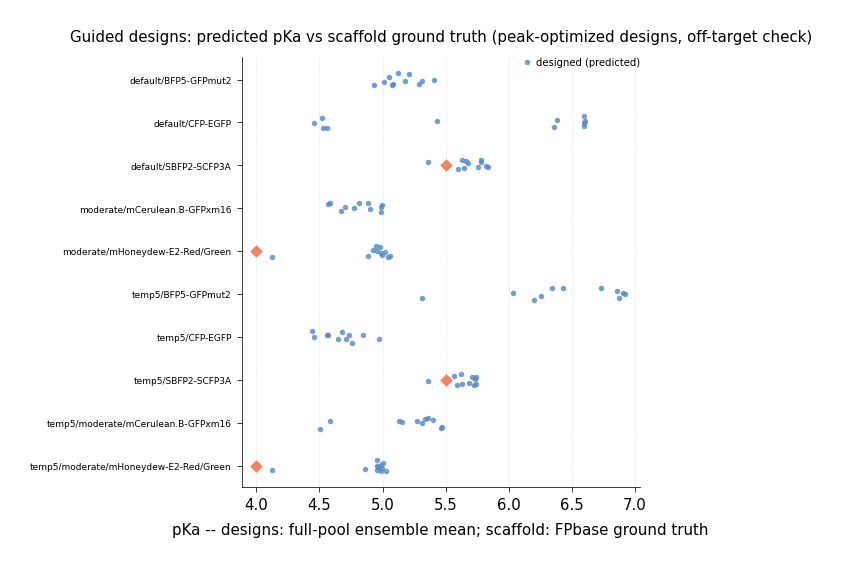

In [14]:
# predicted pKa of each design vs its scaffold, grouped by variant/pair
groups = {}
for d in drows:
    key = f"{d['variant']}/{d['pair']}"
    g = groups.setdefault(key, {'des': [], 'scaf': scaffold_true(d)})
    g['des'].append(k_mean[d['designed_seq']])
keys = sorted(groups)
fig, ax = plt.subplots(figsize=(9, 0.55*len(keys)+2))
for i, k in enumerate(keys):
    des = np.array(groups[k]['des']); jit = (np.random.default_rng(i).random(len(des))-0.5)*0.3
    ax.scatter(des, np.full(len(des), i)+jit, s=30, color=C.aegean, alpha=0.8, label='designed (predicted)' if i==0 else None)
    if np.isfinite(groups[k]['scaf']):
        ax.scatter([groups[k]['scaf']], [i], marker='D', s=80, color=C.amber, edgecolor='k', zorder=3, label='scaffold (FPbase truth)' if i==0 else None)
ax.set_yticks(range(len(keys))); ax.set_yticklabels(keys, fontsize=9); ax.invert_yaxis()
ax.set_xlabel('pKa -- designs: full-pool ensemble mean; scaffold: FPbase ground truth')
ax.set_title('Guided designs: predicted pKa vs scaffold ground truth (peak-optimized designs, off-target check)')
ax.legend(fontsize=10); ax.grid(axis='x', ls=':', alpha=0.5)
plt.tight_layout(); fig.savefig(f'{TDM_K}/guided_designs_pka.png', dpi=130, bbox_inches='tight'); plt.show()

## Notes
- **Target** = pKa = FPbase-reported pH of half-maximal chromophore protonation, per `(protein, state)`.
  Lower pKa means fluorescence survives more acidic environments (more acid-resistant); higher pKa means the
  FP is more pH-sensitive over the physiological range. A sample must be a **fluorescent FP**: it needs a `pka`
  **and** both `ex_max`/`em_max`. Non-emissive chromoproteins (an absorption peak but no `em_max`) are excluded.
- **Dataset build** mirrors `build_peak_dataset.py`: standard-AA sequences only, and each >1-state
  sequence collapsed to one row via the same rule (drop pH/Ca2+ sensors, dedup identical, drop ambiguous,
  keep the min-emission native precursor) so each sequence has a single pKa target with no split leak. Note
  the collapse rule drops multi-state **pH/Ca2+ sensor** constructs (by state name), but single-state
  pH-sensitive FPs -- exactly what a pKa describes -- are kept.
- **Outlier filter** = **cofactor | NN-4mer<0.10 | name~(frFAST|nirFAST)** -- identical to
  `curate_split_visualize.ipynb`. The explicit FAST flag is needed because those sit at NN~0.72 and carry no
  cofactor tag, yet their signal is set by an exogenous fluorogen.
- **Split logic** mirrors `surrogate_oracle_peak_dual.ipynb` (seed 0, 70/15/15, coordinated S/O with disjoint
  val sets and each side's test set fully seen during the other's training).
- **Artifacts** -- raw: `training_data_pka/` (`pka.npy`, `sequences.fasta`, `pka_assignments.csv`,
  `pka_meta.json`); curated: `training_data_pka/curated/` (same plus `keep_index.npy`, `dual_splits.csv`,
  `curate_meta.json`). Embeddings are reused from the peak residue cache by sequence (viz only); no
  re-embedding of cached sequences.
- **No log transform.** Unlike brightness (right-skewed, ~0-165), pKa is bounded and roughly symmetric
  (~0-12, median ~5.4), so it is modeled directly in pH units, standardized on the train split
  (analogous to `StandardizedPeaks`). MAE is reported in pH units.
- **Learning curve (section 6)** trains a CNN regressor on pKa over growing training fractions with a fixed 15%
  test set, mirroring `learning_curve.ipynb`. Every fit's weights are cached to `trained_models_pka/lc_models/`
  and the sweep summary to `trained_models_pka/pka_learning_curve_sweep.json`, so re-running the notebook
  reloads instead of retraining. Use it to judge whether the training pool is on the plateau and how large the
  train-vs-test gap is -- the evidence for whether the dual surrogate/oracle split is worth its holdout cost.
- **Guided-design scoring (section 7)** reloads the six full-pool checkpoints and predicts pKa for every design
  sequence in `peak_designs/` (ensemble mean +/- std); each **scaffold uses its FPbase ground-truth** pKa
  (by sequence) as the baseline. Writes `peak_designs/pka_scored.csv` (with both `scaffold_pka_true` and the
  model's `scaffold_pka_pred`) and `trained_models_pka/guided_designs_pka.png`. Those designs were optimized
  for peak, so this is an off-target check; trust the relative ranking over exact values.